# Homework: Calculate the heat capacity of ethane at different pressures

The argument we made for using departure functions is that the heat capacity for a real substance depends on pressure (or molar volume). Here we will calculate the constant pressure heat capacity at different pressures for ethane.

SIS is Stanley I. Sandler, *Chemical, Biochemcial and Engineering Thermodynamics*, 5th ed.

Eric Furst  
November 2025

----

As ususal, we import the *numpy* and *matplotlib* libraries. We'll also use the *SciPy* constants library.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
import scipy.optimize as opt

R = constants.R # Set the gas constant to R

## Problem statement

Using a Jupyter Notebook, plot the constant pressure heat capacity of ethane between 30°C and 200°C for the pressures 0.1, 2, and 4 MPa. Compare these to the ideal gas values $ C_p (T) $ given by the correlation in Appendix A.II.

To solve this problem, I will calculate the enthalpy of ethane as a function of temperature at constant pressure. From these values, I will take the numerical derivative to find

$$ C_p(T) = \left ( \frac{\partial \underbar{H}}{\partial T} \right )_P \approx \left ( \frac{\Delta \underbar{H}}{\Delta T} \right ) _P .$$

The change in enthalpy will be calculated with departure functions
$$ \Delta \underline{H} = \Delta \underline{H}^\mathrm{IG} + \Delta [ \underline{H} - \underline{H}^\mathrm{IG}] $$


or

$$\Delta \underbar{H} = \Delta \underline{H}^\mathrm{IG} + [ \underline{H} - \underline{H}^\mathrm{IG}]_2 - [ \underline{H} - \underline{H}^\mathrm{IG}]_1.$$

The specific departure functions we will use are derived from the generalized Peng-Robinson equation of state. 

# Generalized Peng-Robinson Equation of State

The Generalized Peng-Robinson equation of state is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with

$$ b = 0.07780 \frac{RT_c}{P_c} \tag{Eq. 6.7-2}$$
$$ a(T) = a(T_c)\alpha(T) = 0.45724 \frac{R^2T_c^2}{P_c}\alpha(T) \tag{Eq. 6.7-1}$$
$$ \sqrt{\alpha} = 1 + \kappa \left ( 1- \sqrt{\frac{T}{T_c}} \right ) \tag{Eq. 6.7-3}$$
$$ \kappa = 0.37464 + 1.54226\omega − 0.26992\omega^2 \tag{Eq. 6.7-4}$$

The acentric factor $\omega$ and the crticial temperatures and pressures are given in SIS table 6.6-1.

Calculating the pressure $P$ given $\underline{V}$ and $T$ is straightforward, but to calculate the molar volume given $P$ and $T$, we need to solve the cubic equation of state of the form

$$ Z^3 + \alpha Z^2 + \beta Z + \gamma = 0 \tag{Eq. 6.4-4}$$

where $Z$ is the compressibility factor

$$ Z = \frac{P \underbar{V{}}}{RT} $$

For the Peng-Robinson EOS,

$$ \alpha = -1 + B $$
$$ \beta = A - 3B^2 -2B $$
$$ \gamma = -AB + B^2 + B^3 $$

and 

$$ A = \frac{aP}{(RT)^2} $$
$$ B = \frac{bP}{RT} $$

In [2]:
"""
Generalized Peng-Robinson EOS 
PR_pressure returns the pressure given V, T, Pc, Tc, omega
PR_volume returns all molar volumes (real roots of EOS) given P, T, Pc, Tc, omega
"""

from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R # Set the gas constant to R

def calc_b(Pc,Tc):
    return 0.07780*R*Tc/Pc

def calc_a(T,Pc,Tc,omega):
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    sqrtalpha = 1 + kappa*(1-np.sqrt(T/Tc))
    return 0.45724*R**2*Tc**2/Pc*sqrtalpha**2

# Calculate the presure given V, T for PR EOS
def PR_pressure(V,T,Pc,Tc,omega):
    a = calc_a(T,Pc,Tc,omega)
    b = calc_b(Pc,Tc)

    P = R*T/(V-b) - a/(V*(V+b)+b*(V-b))
    return P

# Solve for the compressibility factor given P, T for PR EOS in m^3/mol
# Note that we can return multiple real roots (up to three)
# The largest and smallest will be the vapor and liquid, respectively
def PR_compressibility(P, T, Pc, Tc, omega):
    # Calculate a, b, A, and B
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    A = a*P/R**2/T**2
    B = b*P/R/T

    # Definitions of alpha, beta, gamma in SIS Table 6.4-3 for PR EOS
    alpha = -1 + B
    beta = A - 3*B**2 -2*B
    gamma = -A*B + B**2 + B**3

    # polynomial with coefficients in increasing order: c0 + c1 x + c2 x**2 + ...
    p = Polynomial([ gamma, beta, alpha, 1 ])  

    roots = p.roots()        # returns all (possibly complex) roots of Z
    real_roots = roots.real[abs(roots.imag) < 1e-12]  # filter real ones

    return real_roots



## Data for ethane

For ethane, we need the critical pressure and temperature and Pitzer's acentric factor:

$P_c = 4.884$ MPa   
$T_c = 305.4$ K  
$\underline{V}_c = 0.184\,\mathrm{m^3/kmol} = 9.9\times10^{-5}\,\mathrm{m^3/mol}$  
$\omega = 0.098$  

We also need heat capacity data in the ideal state. We use the empirical equation in SIS A.II:

$$ C^*_p(T) = A + BT + CT^2 + DT^3 $$

The code block below has values for several molecules, including ethane.

In [3]:
# Critical values for Ethane and the acentric factor
# pressure in Pa, temperature in K
Pc = 4.884e6
Tc = 305.4
omega = 0.098

# Heat capacity data for N2, O2, CO2, CH4, C2H6
params = np.array([
    [28.83, -0.157, 0.808, -2.871, 1800],
    [25.46, 1.519, -0.715, 1.311, 1800],
    [22.243, 5.977, -3.499, 7.464, 1800],
    [19.875, 5.021, 1.268, -11.004, 1500],
    [6.895, 17.255, -6.402, 7.280, 1500]
    ])

i = params[4,:]  # equation parameters for ethane

## Function to calculate the heat capacity $C_p^*(T)$

Here, the ideal state constant pressure heat capacity $ C_p^*(T)$ is given by an empirical equation

$$ C_p^*(T) = a + bT + cT^2 + dT^3 \tag{Table A.II}$$

where $T$ is in absolute temperature Kelvins and $C_p^*$ is in units J/(mol K).

In [4]:
# Calculate the heat capacity using SIS correlation in Appendix A.II

def calc_Cp_IG(T, params):
    A, B, C, D = params[:]
    B *= 10**-2
    C *= 10**-5
    D *= 10**-9
    return A + B*T + C*T**2 + D*T**3

## Function to calculate the enthalpy change in the ideal state
$$\Delta\underline{H}^\mathrm{IG} = \int_{T_1}^{T_2}C_p^*(T)dT$$
where we will use the ideal state heat capacities summarized in SIS Appendix A.II,
$$C^*_p(T) = A + BT + CT^2 + DT^3$$
resulting in
$$\Delta\underline{H}^\mathrm{IG} = A(T_2-T_1) + \frac{1}{2}B(T_2^2 - T_1^2)+ \frac{1}{3}C(T_2^3 - T_1^3) + \frac{1}{4}D(T_2^4 - T_1^4)$$

In [5]:

def calc_deltaH_IG(T1,T2,params):
    A, B, C, D = params[:4]
    B *= 10**-2
    C *= 10**-5
    D *= 10**-9
    deltaHIG = A*(T2-T1) + B*(T2**2-T1**2)/2 + C*(T2**3-T1**3)/3 + D*(T2**4-T1**4)/4
    return deltaHIG

## Function for Generalized Peng-Robinson departure function 
The enthalpy departure function in $(P,T)$ control variables for the Peng-Robinson equuation of state is

$$[\underline{H} - \underline{H}^\mathrm{IG}] = RT(Z-1) + \frac{T\frac{da}{dT}-a}{2\sqrt2 b}\ln \left [ \frac{Z+(1+\sqrt2)B}{Z+(1-\sqrt2)B} \right ] \tag{Eq. 6.4-29}$$

where we need to evaluate the compressibility factor,
$$Z = \frac{P\underline{V}}{RT}$$
the scaled value of $b$,
$$B = \frac{bP}{RT}$$
and the deriviative of $a(T)$ with respect to temperature given in SIS (p. 264),
$$\frac{da}{dT} = - 0.45724 \frac{R^2T_c^2}{P_c} \kappa \sqrt{\frac{\alpha}{T T_c}}$$

In [6]:
# With Z already calculated, we define a function to calculate the departure function

"""
Enthalpy departure function from the Peng-Robinson equation of state (eq. 6.4-29)
For convenience, we recalculate b, kappa, sqrtalpha, and a(T) here, but we could
use the earlier functions, too.

Uses globals Tc, Pc, R
"""
def calc_depH(T,P,Z):
    b = 0.07780*R*Tc/Pc
    B = b*P/R/T
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    sqrtalpha = 1 + kappa*(1-np.sqrt(T/Tc))
    a = 0.45724*R**2*Tc**2/Pc*sqrtalpha**2
    dadT = -0.45724*R*R*Tc*Tc/Pc*kappa*sqrtalpha/(T*Tc)**0.5

    depH = R*T*(Z-1)+(T*dadT-a)/(2*np.sqrt(2)*b) \
        *np.log((Z+(1+np.sqrt(2))*B)/(Z+(1-np.sqrt(2))*B))
    return depH

# Enthalpy calculation function

We will define a function to calculate the enthalpy.

In [7]:
def del_H(T1, T2, P1, P2, params):
    '''
    params should include: A, B, C, D for Cp correlation    '''

    # Calculate the compressibility factor
    # Use the maximum value in case there are multiple roots
    Z1 = np.max(PR_compressibility(P1,T1,Pc,Tc,omega))

    # Calculate the first departure function
    depH1 = calc_depH(T1,P1,Z1)

    # Calculate the compressibility factor
    # Use the maximum value in case there are multiple roots
    Z2 = np.max(PR_compressibility(P2,T2,Pc,Tc,omega))

    # Calculate the second departure function
    depH2 = calc_depH(T2,P2,Z2)

    # Calculate the ideal gas contribution
    deltaH_IG = calc_deltaH_IG(T1,T2,params)

    # Add for the total change in enthalpy
    return deltaH_IG + (depH2 - depH1)


# Routine to calculate heat capacity

Text(0.5, 1.0, 'Heat capacity for ethane at different pressures')

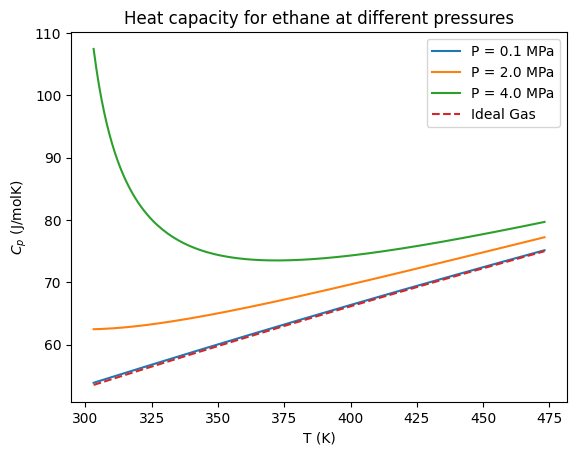

In [8]:
# Known values in problem
# The initial and final temperatures are
Ti = 30 + 273.15     # Beginning temperature in K
Tf = 200 + 273.15    # final temperature in K
delta_T = 1 # use increments to calculate numerical derivative

fig, ax = plt.subplots()

for P in [0.1e6, 2e6, 4e6]:

    T = np.arange(Ti, Tf + 1, delta_T)

    cp_values = np.zeros_like(T, dtype=float)

    for idx, T0 in enumerate(T):
        # Compute ΔH over 1 K interval for each temperature
        dH = del_H(T0, T0 + delta_T, P, P, i[:4])
        cp_values[idx] = dH / delta_T

    ax.plot(T, cp_values, label=f'P = {P/1e6:.1f} MPa')

cp_ideal = calc_Cp_IG(T, i[:4])
ax.plot(T, cp_ideal, '--', label='Ideal Gas')

ax.legend()
plt.xlabel('T (K)')
plt.ylabel("$C_p$ (J/molK)")
plt.title('Heat capacity for ethane at different pressures')

This makes sense. The isotherms on the pressure-enthalpy plot tend to bend toward lower values of enthalpy with higher pressures. That is, $(\partial P/\partial \underbar{H})_T$ has a lower and negative slope on the plot. Thus, at $P = 4$ MPa, for each 10 degree difference in temperature, there is nearly double the amount of enthalpy change. Pretty interesting!

Second, the non-lienar behavior also makes sense. This isobar eventually intersects the VLE curve (it’s below the critical pressure) and so you expect the heat capacity to diverge! Why? Think of the intersecting isotherm and what the slope represented by looks like in the VLE region. Then, as you go to higher temperatures along the isobar away from the VLE curve, you begin to recover more ideal-like behavior (and its temperature dependence).